> Para el desarrollo se utilizó IA generativa como guía para revisar en que mejorar la redacción de las respuestas, y para parte del codigo del análisis de resultados siempre revisando que sea adecuado y correcto para nuestro caso.

### Notebook 1:  Clustering con K-means
En este notebook vamos a implementar el algoritmo de clustering K-means en R. El objetivo es entender como funciona este algoritmo y  aprender a utilizarlo con un ejemplo simple. Se incluye además la estrategia para definir el número de grupos k. Al final se propone un ejercicio con nuevos datos, con el fin de aprender a utilizar el algoritmo. 

Para ello vamos a utilizar un conjunto de datos provenientes de un estudio de granos pertenecientes a distintas variedades de trigo. Los atributos de los datos provienen de una visualización de alta calidad de la estructura interna del grano utilizando una técnica de rayos X suaves. La ventaja de esta técnica es que no es destructiva y es considerablemente más económica que otras técnicas de imagen más sofisticadas como la microscopía de barrido o la tecnología láser. Las imágenes se registraron en placas KODAK de rayos X de 13x18 cm. Los estudios se llevaron a cabo utilizando grano de trigo cosechado en combinación procedente de campos experimentales, explorados en el Instituto de Agrofísica de la Academia de Ciencias de Polonia en Lublin.

Los atributos observados son seis parámetros geométricos medidos en los granos de trigo:

V1: área A

V2: perímetro P

V3: longitud de la semilla

V4: ancho de la semilla

V5: coeficiente de asimetría

V6: longitud de la ranura de la semilla

Se trata de analizar de que manera estos atributos permiten generar grupos en los datos que correspondan idealmente a cada variedad de trigo disponible en los datos.

In [1]:
library(cluster)
library(ggplot2)
library(factoextra)
library(patchwork)
library(gridExtra)
library(ggplotify)
library(fastDummies)

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



In [2]:
# Para hacer los graficos mas grandes
options(repr.plot.width = 25, repr.plot.height = 8) 

### **Ejercicio 1:**

1) De acuerdo al gráfico obtenido, cuál es el valor de K mas apropiado? Explique su decisión.
2) Realice nuevamente los cálculos con el K óptimo y caracterice los grupos obtenidos. Interprete sus resultados

       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6       
 Min.   :0.765   Min.   :4.519  
 1st Qu.:2.562   1st Qu.:5.045  
 Median :3.599   Median :5.223  
 Mean   :3.700   Mean   :5.408  
 3rd Qu.:4.769   3rd Qu.:5.877  
 Max.   :8.456   Max.   :6.550  

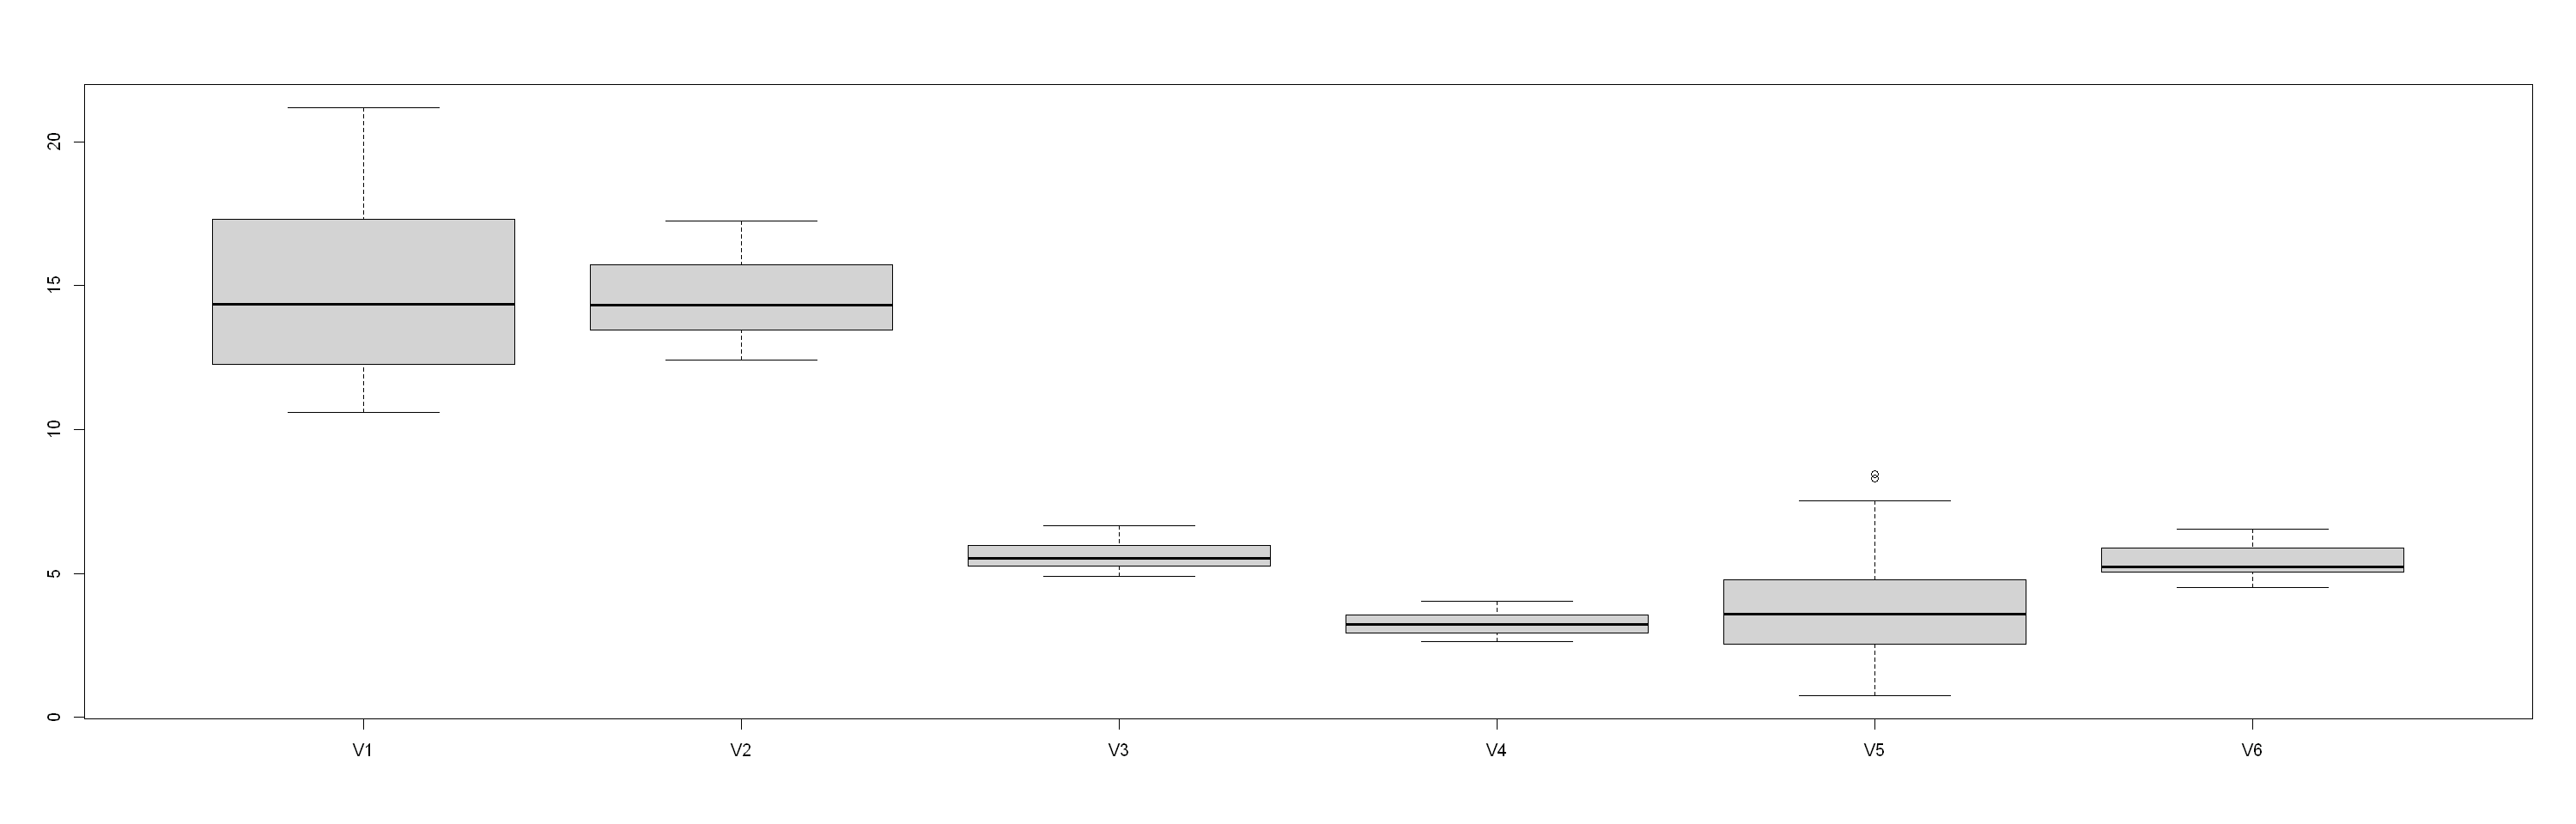

In [3]:
datos <-read.table("..//data//semillas1.txt",dec=".")
summary(datos)
boxplot(datos)

Call:
princomp(x = datos, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


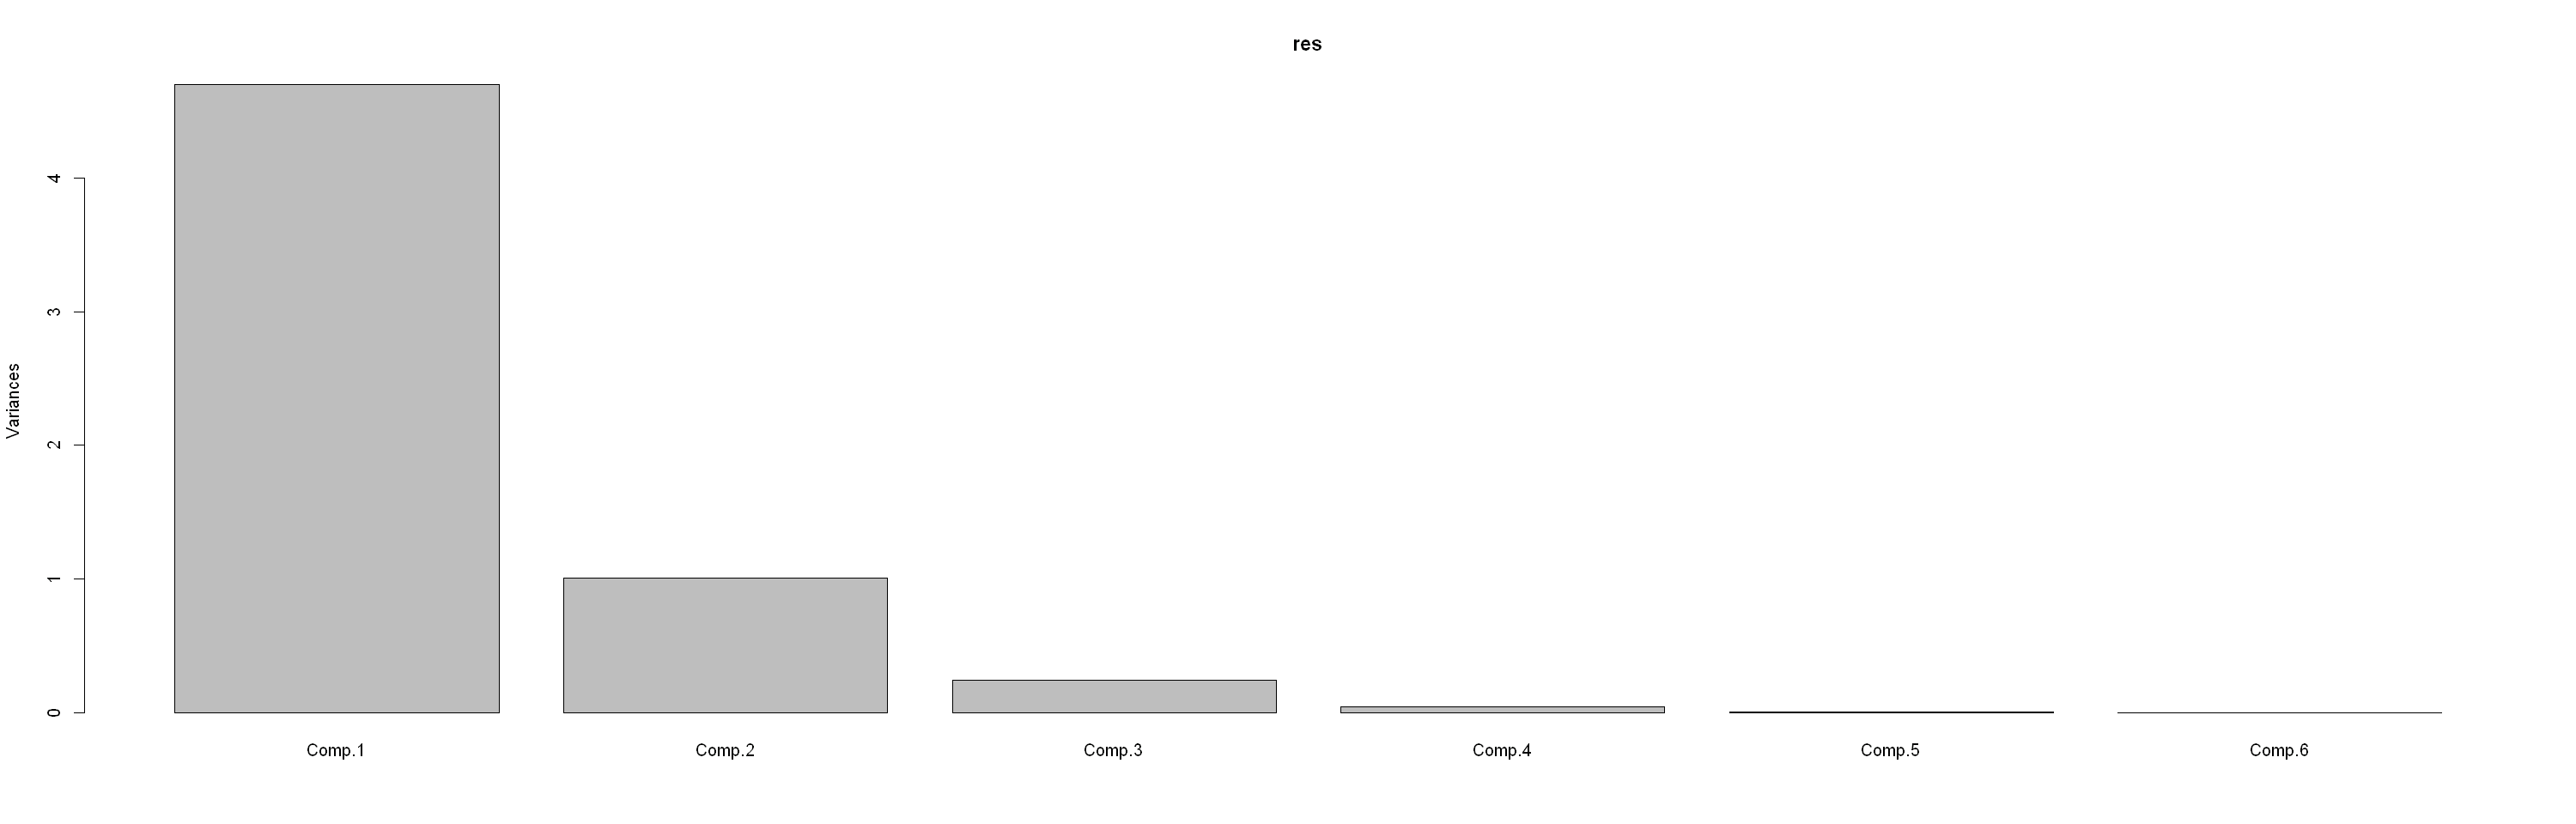

In [4]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos, cor=TRUE)
print(res)
plot(res)

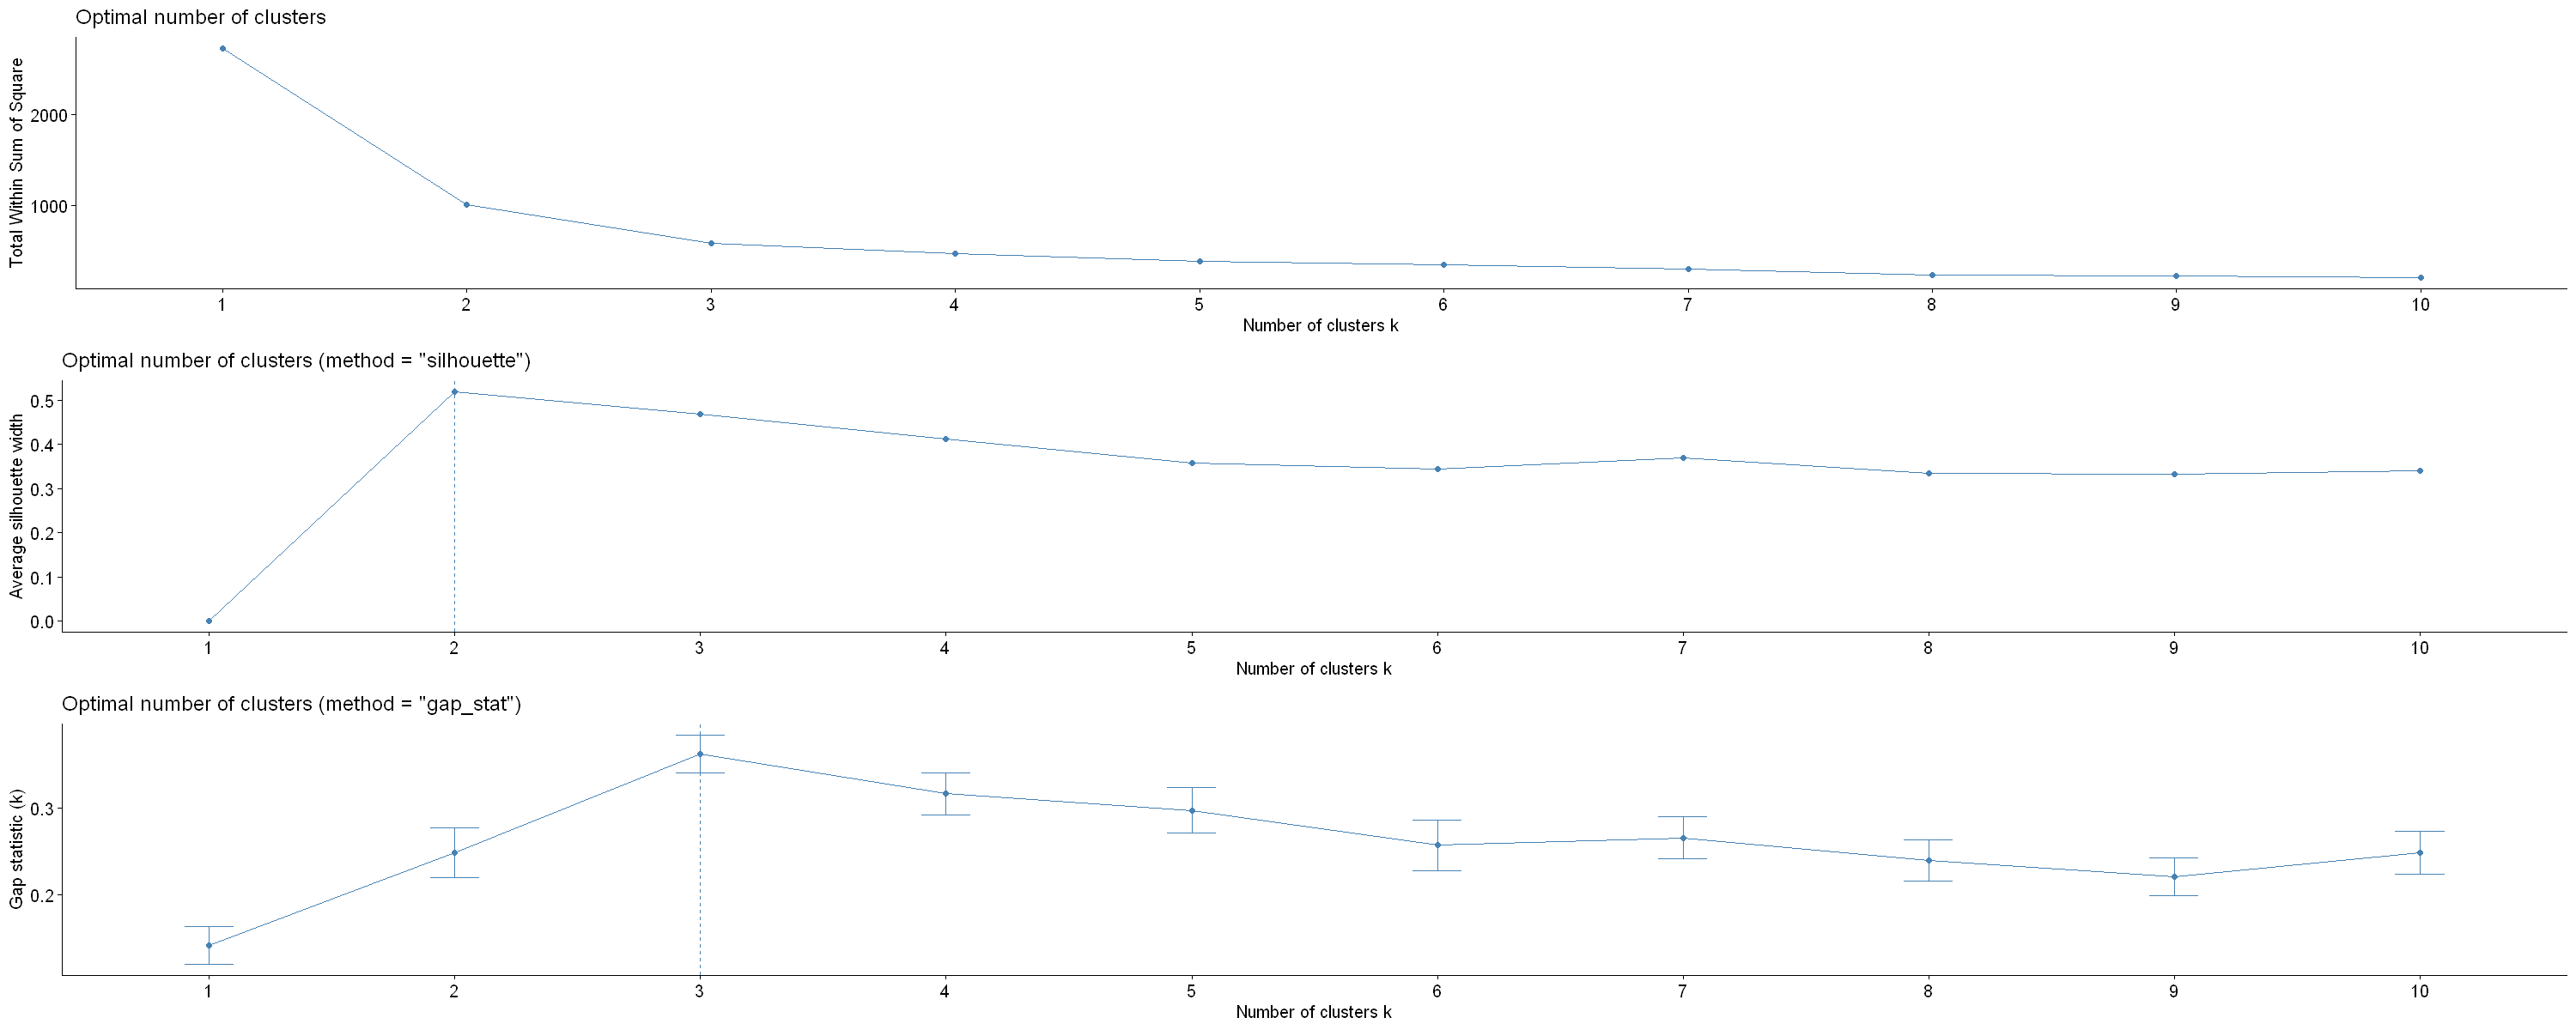

In [5]:
## Graficos de seleccion de K

### El "Codo" en formato ggplot
g1 <- fviz_nbclust(datos, kmeans, method = "wss")

### Análisis de Silueta (Busca el máximo)
g2 <- fviz_nbclust(datos, kmeans, method = "silhouette")

### Estadística Gap (Busca la mayor desviación del azar)
g3 <- fviz_nbclust(datos, kmeans, method = "gap_stat")

# # Por si se quiere algo mas experimentable
# gap_stat <- clusGap(df,
#     FUN = kmeans,
#     nstart = 25,
#     K.max = 10,
#     B = 50
# )

options(repr.plot.height = 10) 
# fviz_gap_stat(gap_stat)
grid.arrange(g1, g2, g3, ncol = 1)
options(repr.plot.height = 8) 

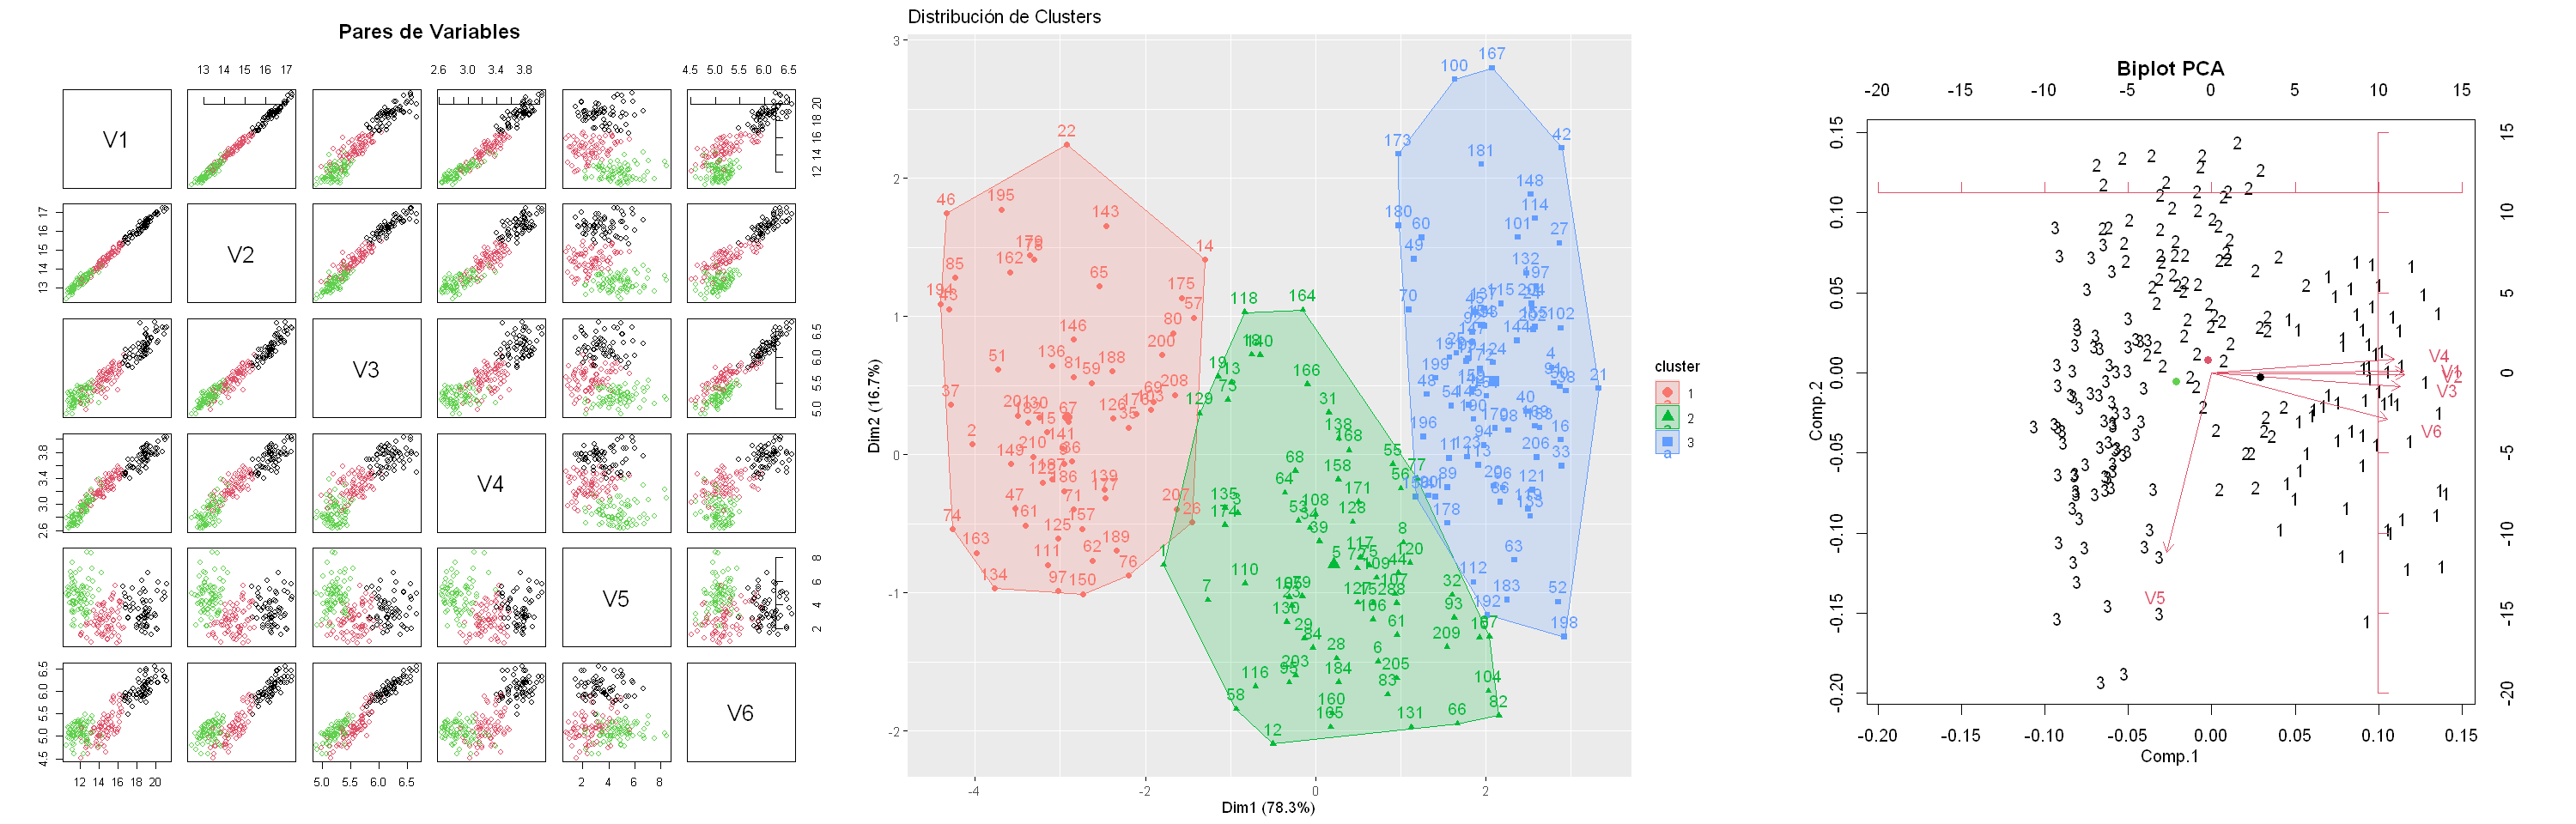

In [6]:
## Visualizacion de k
k0=3
cl<-kmeans(datos,k0,iter.max=1000,nstart=10)

res <- princomp(datos, cor=TRUE)
res2 <- predict(res, cl$centers)

# 1.
p1 <- as.grob(~pairs(datos, col=cl$cluster, main="Pares de Variables"))

# 2. 
p2 <- fviz_cluster(cl, datos, main = "Distribución de Clusters")

# 3.
p3 <- as.grob(~{
  biplot(res, xlabs=cl$cluster, main="Biplot PCA")
  points(res2[,1:2], col=1:k0, pch=19)
})

grid.arrange(p1, p2, p3, ncol = 3)

#### **Respuestas**

1. De acuerdo al gráfico obtenido, cuál es el valor de K mas apropiado? Explique su decisión.
   
    Tras analizar los tres criterios de selección, se determina que **$K=3$** es el valor más adecuado para este conjunto de datos. 
    El Método del Codo (WSS) muestra una disminución drástica de la inercia hasta el valor de 3, punto a partir del cual la ganancia de información se vuelve marginal. Aunque el Análisis de Silueta sugiere un $K=2$, este tiende a ser un método conservador que prioriza la separación absoluta de las fronteras de los grupos, sin embargo, la Estadística Gap identifica un pico claro en K=3, indicando que existe una estructura de tres grupos con una varianza interna significativamente menor a la de una distribución aleatoria. 
    Finalmente, la elección de $K=3$ tiene una sólida justificación en los datos, ya que el conjunto de datos representa tres variedades reales de trigo (Kama, Rosa y Canadian), lo que permite que el modelo recupere la estructura natural de los datos.

2. Realice nuevamente los cálculos con el K óptimo y caracterice los grupos obtenidos. Interprete sus resultados
    
    Al ejecutar el algoritmo con el valor óptimo de **K=3**, se obtiene una segmentación clara y coherente. Visualizando los resultados en el plano de los Componentes Principales (PCA) y analizando los centroides de cada cluster, podemos caracterizar los grupos de la siguiente manera:

    1) **Grupo de Semillas Grandes (Rosa):** Presenta los valores más altos en área ($V1$) y perímetro ($V2$), lo que indica semillas morfológicamente más robustas.
    2) **Grupo de Semillas Estrechas/Pequeñas (Canadian):** Se caracteriza por dimensiones menores en casi todas las variables, pero con una relación de longitud/ancho específica.
    3) **Grupo de Semillas Asimétricas (Kama):** Presenta valores intermedios de volumen, pero destaca por un mayor coeficiente de asimetría ($V5$).

    En conclusión, las variables de **Área y Perímetro** son los descriptores que mejor discriminan entre los grupos, permitiendo una separación casi total de las nubes de puntos con muy poco solapamiento, lo que valida la efectividad del clustering para diferenciar variedades botánicas basadas únicamente en su geometría."

### **Ejercicio 2:**
Realice un análisis de clustering con el conjunto de datos correspondiente a su grupo, para el cual ya realizó un análisis exploratorio y de PCA (No olvide de excluir la penúltima y última columna de sus datos originales).

1. Describa los datos y discuta la pertinencia de realizar un análisis de clustering o agrupamiento
2. Utilice k-means para realizar el clustering de los datos y calcule el K óptimo. 
3. Caracterice los grupos obtenidos con el K óptimo. Interprete sus resultados

   distancia          tiempo          velocidad         modo_transporte_bus
 Min.   : 0.020   Min.   :0.05733   Min.   :  0.01573   Min.   :0.0000     
 1st Qu.: 8.675   1st Qu.:0.53700   1st Qu.: 12.12287   1st Qu.:0.0000     
 Median :15.615   Median :0.78542   Median : 18.95680   Median :0.0000     
 Mean   :16.820   Mean   :0.84357   Mean   : 26.45919   Mean   :0.3302     
 3rd Qu.:22.878   3rd Qu.:1.04221   3rd Qu.: 31.72714   3rd Qu.:1.0000     
 Max.   :77.310   Max.   :4.23100   Max.   :157.50000   Max.   :1.0000     
 modo_transporte_bicicleta modo_transporte_auto modo_transporte_caminar
 Min.   :0.0000            Min.   :0.0000       Min.   :0.0000         
 1st Qu.:0.0000            1st Qu.:0.0000       1st Qu.:0.0000         
 Median :0.0000            Median :0.0000       Median :0.0000         
 Mean   :0.3767            Mean   :0.1047       Mean   :0.1512         
 3rd Qu.:1.0000            3rd Qu.:0.0000       3rd Qu.:0.0000         
 Max.   :1.0000            Max.   :1

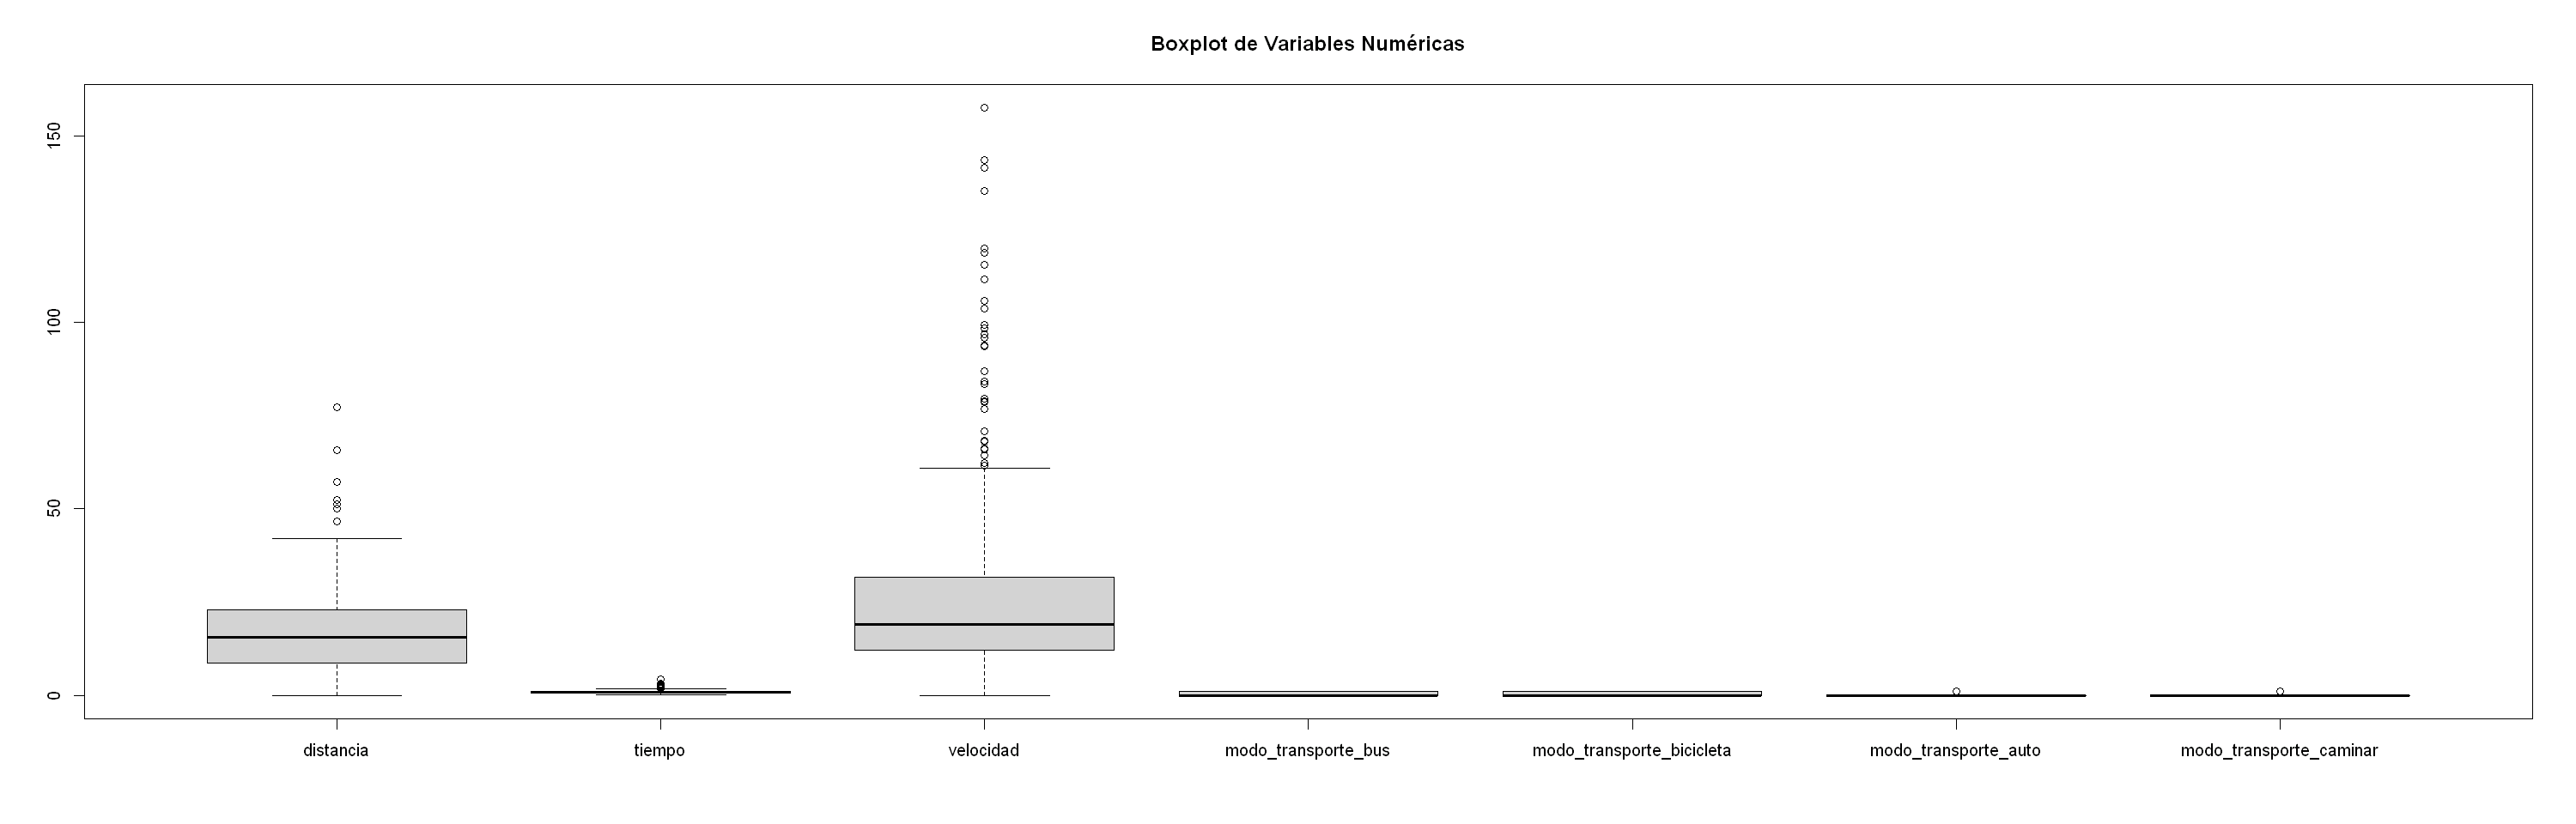

In [7]:
# Se cargan los datos originales
datos_grupo <- read.csv("..//datasets_simulados//Grupo10.csv", dec=".", sep=",")

datos_grupo <- dummy_cols(datos_grupo, select_columns = "modo_transporte", remove_selected_columns = FALSE)

# Se filtran valores negativos y nulos (Ya que no tienen sentido logico)
datos_grupo <- datos_grupo[datos_grupo$distancia > 0 & datos_grupo$tiempo > 0 & datos_grupo$viajes > 0, ]
datos_grupo <- na.omit(datos_grupo)

# Agregamos velocidad (en kilometros) promedio antes de filtrar. Tambien quitamos velocidades que no tienen sentido 
# (Velocidades sobre 160 kilometros por hora, teniendo en cuenta que la velocidad maxima en chile es 120km/h en autopista y que algunos trenes efe podrian llegar a 160km/h en algunos tramos).
datos_grupo$tiempo <- datos_grupo$tiempo / 60
datos_grupo$velocidad <- datos_grupo$distancia / datos_grupo$tiempo
datos_grupo <- datos_grupo[datos_grupo$velocidad <= 160, ]

# Solo usamos los datos numericos.
datos_grupo_numericos <- datos_grupo[ , c("distancia", "tiempo", "velocidad", "modo_transporte_bus", "modo_transporte_bicicleta", "modo_transporte_auto", "modo_transporte_caminar")]

summary(datos_grupo_numericos)
boxplot(datos_grupo_numericos, main="Boxplot de Variables Numéricas")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.05733 0.53700 0.78542 0.84357 1.04221 4.23100 

Call:
princomp(x = datos_grupo_numericos, cor = TRUE)

Standard deviations:
   Comp.1    Comp.2    Comp.3    Comp.4    Comp.5    Comp.6    Comp.7 
1.4444044 1.2108115 1.1565284 1.0958000 0.8338227 0.4011151 0.2305259 

 7  variables and  424 observations.


     viajes         distancia          tiempo        modo_transporte   
 Min.   : 0.120   Min.   : 0.020   Min.   :0.05733   Length:430        
 1st Qu.: 2.400   1st Qu.: 8.675   1st Qu.:0.53700   Class :character  
 Median : 3.170   Median :15.615   Median :0.78542   Mode  :character  
 Mean   : 3.358   Mean   :16.820   Mean   :0.84357                     
 3rd Qu.: 4.003   3rd Qu.:22.878   3rd Qu.:1.04221                     
 Max.   :12.460   Max.   :77.310   Max.   :4.23100                     
   congestion      alta_congestion    modo_transporte_  modo_transporte_auto
 Min.   :-1087.0   Length:430         Min.   :0.00000   Min.   :0.0000      
 1st Qu.:  326.1   Class :character   1st Qu.:0.00000   1st Qu.:0.0000      
 Median :  650.1   Mode  :character   Median :0.00000   Median :0.0000      
 Mean   :  748.7                      Mean   :0.01163   Mean   :0.1047      
 3rd Qu.: 1107.4                      3rd Qu.:0.00000   3rd Qu.:0.0000      
 Max.   : 3152.3                  

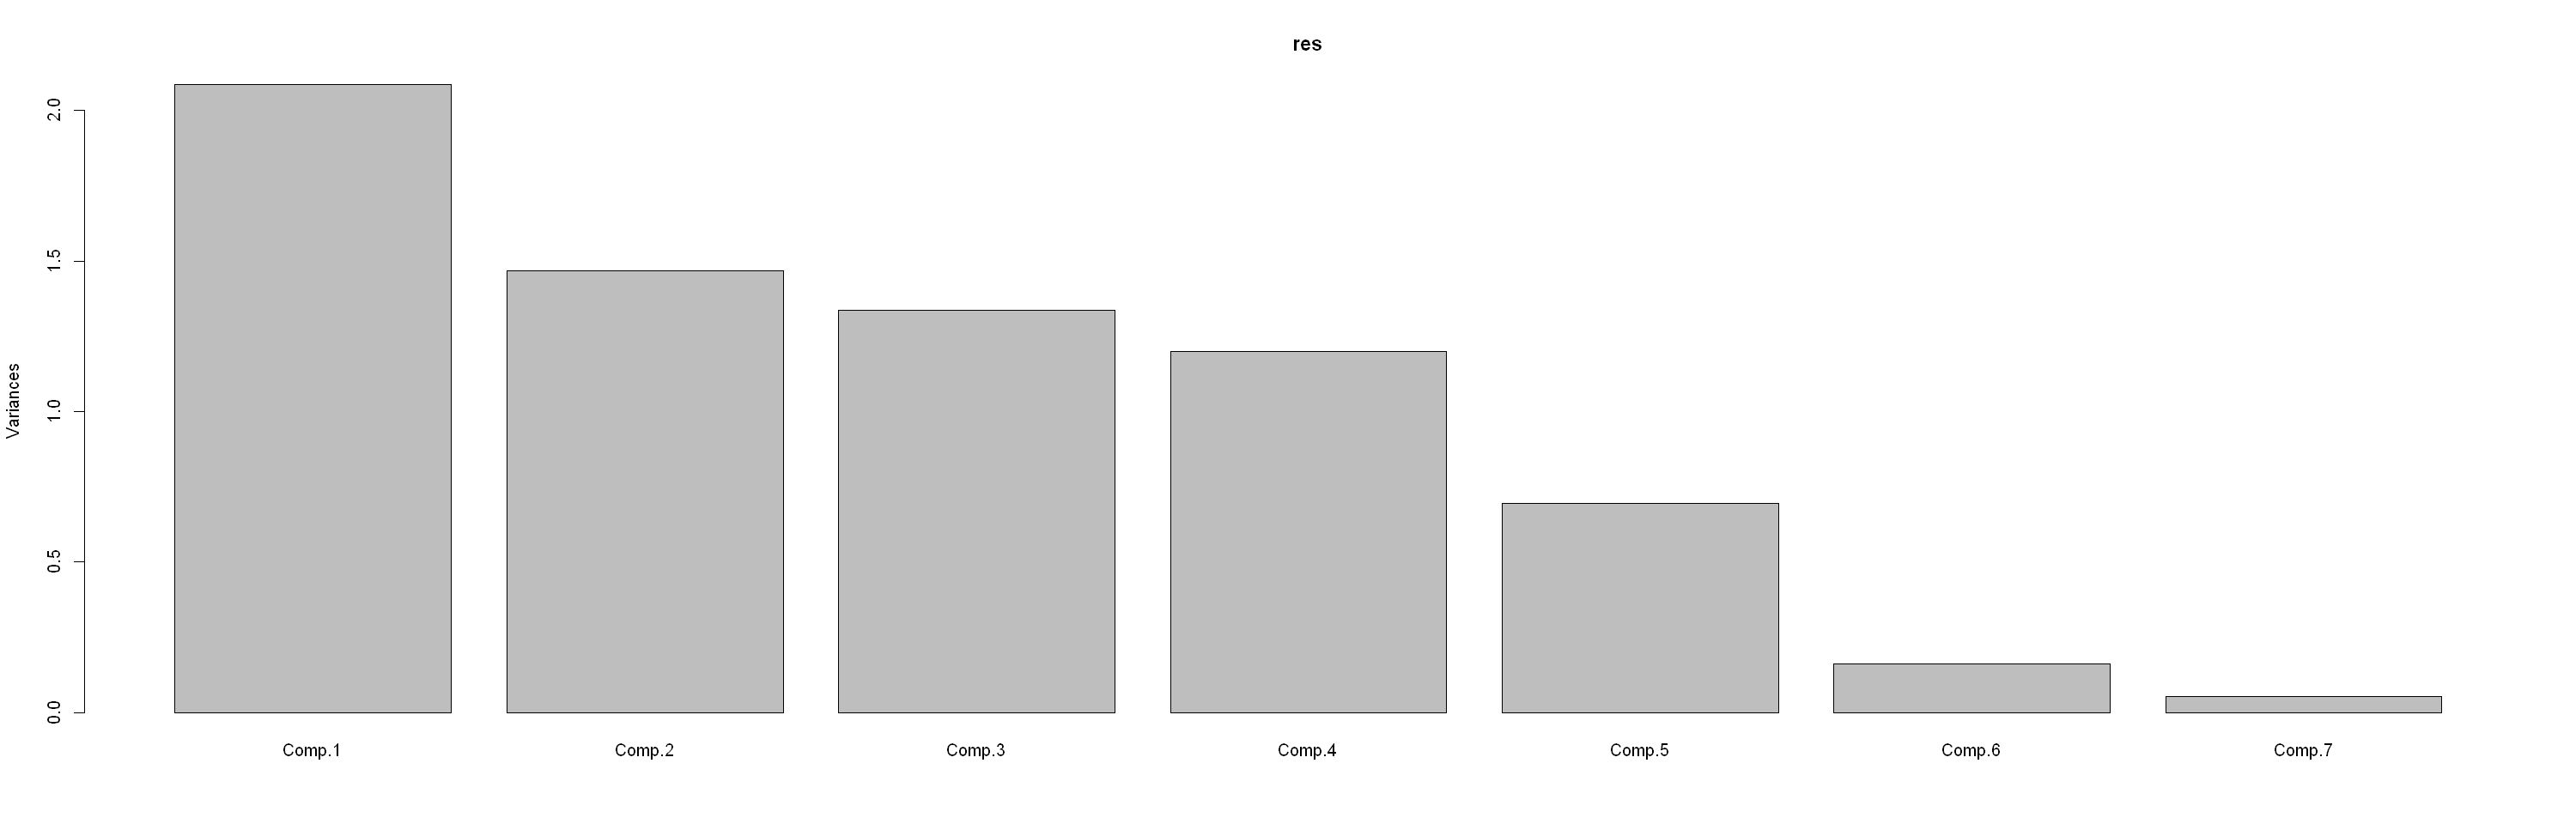

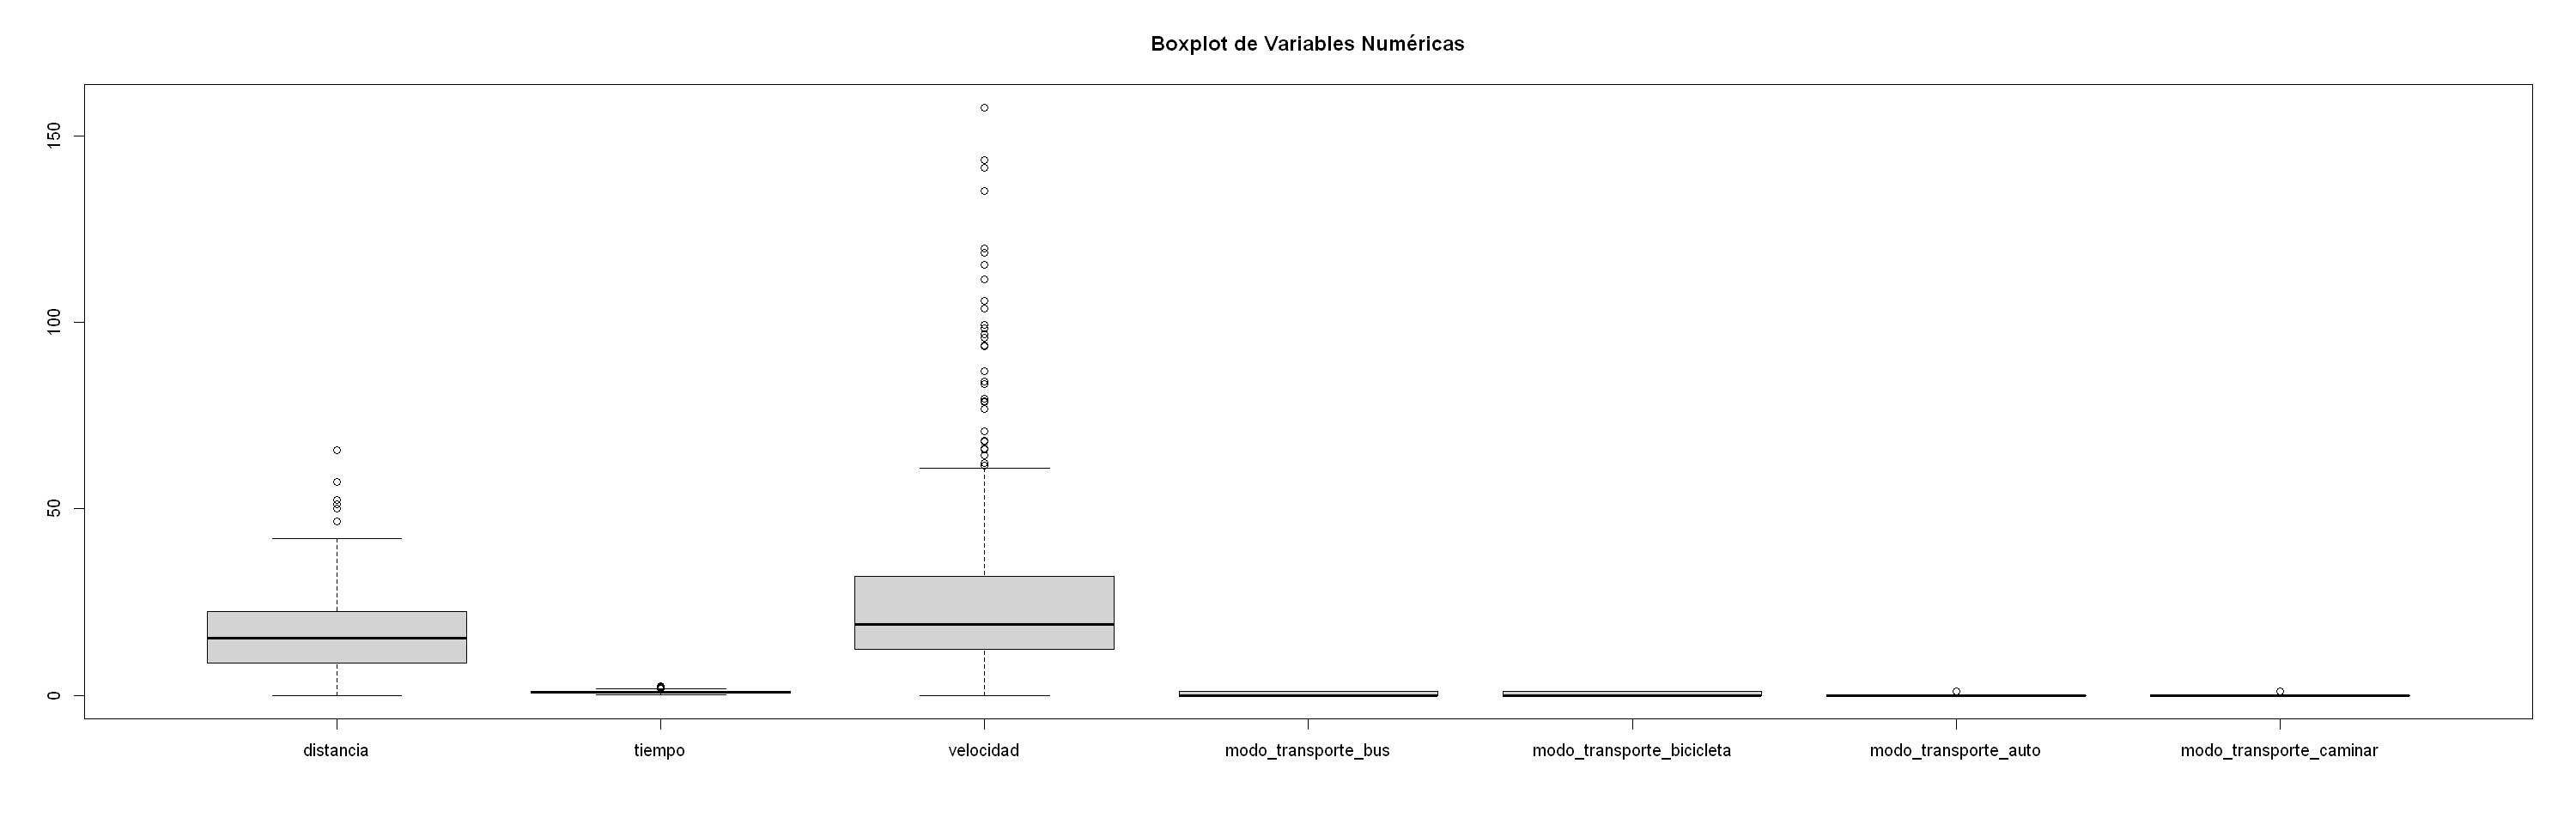

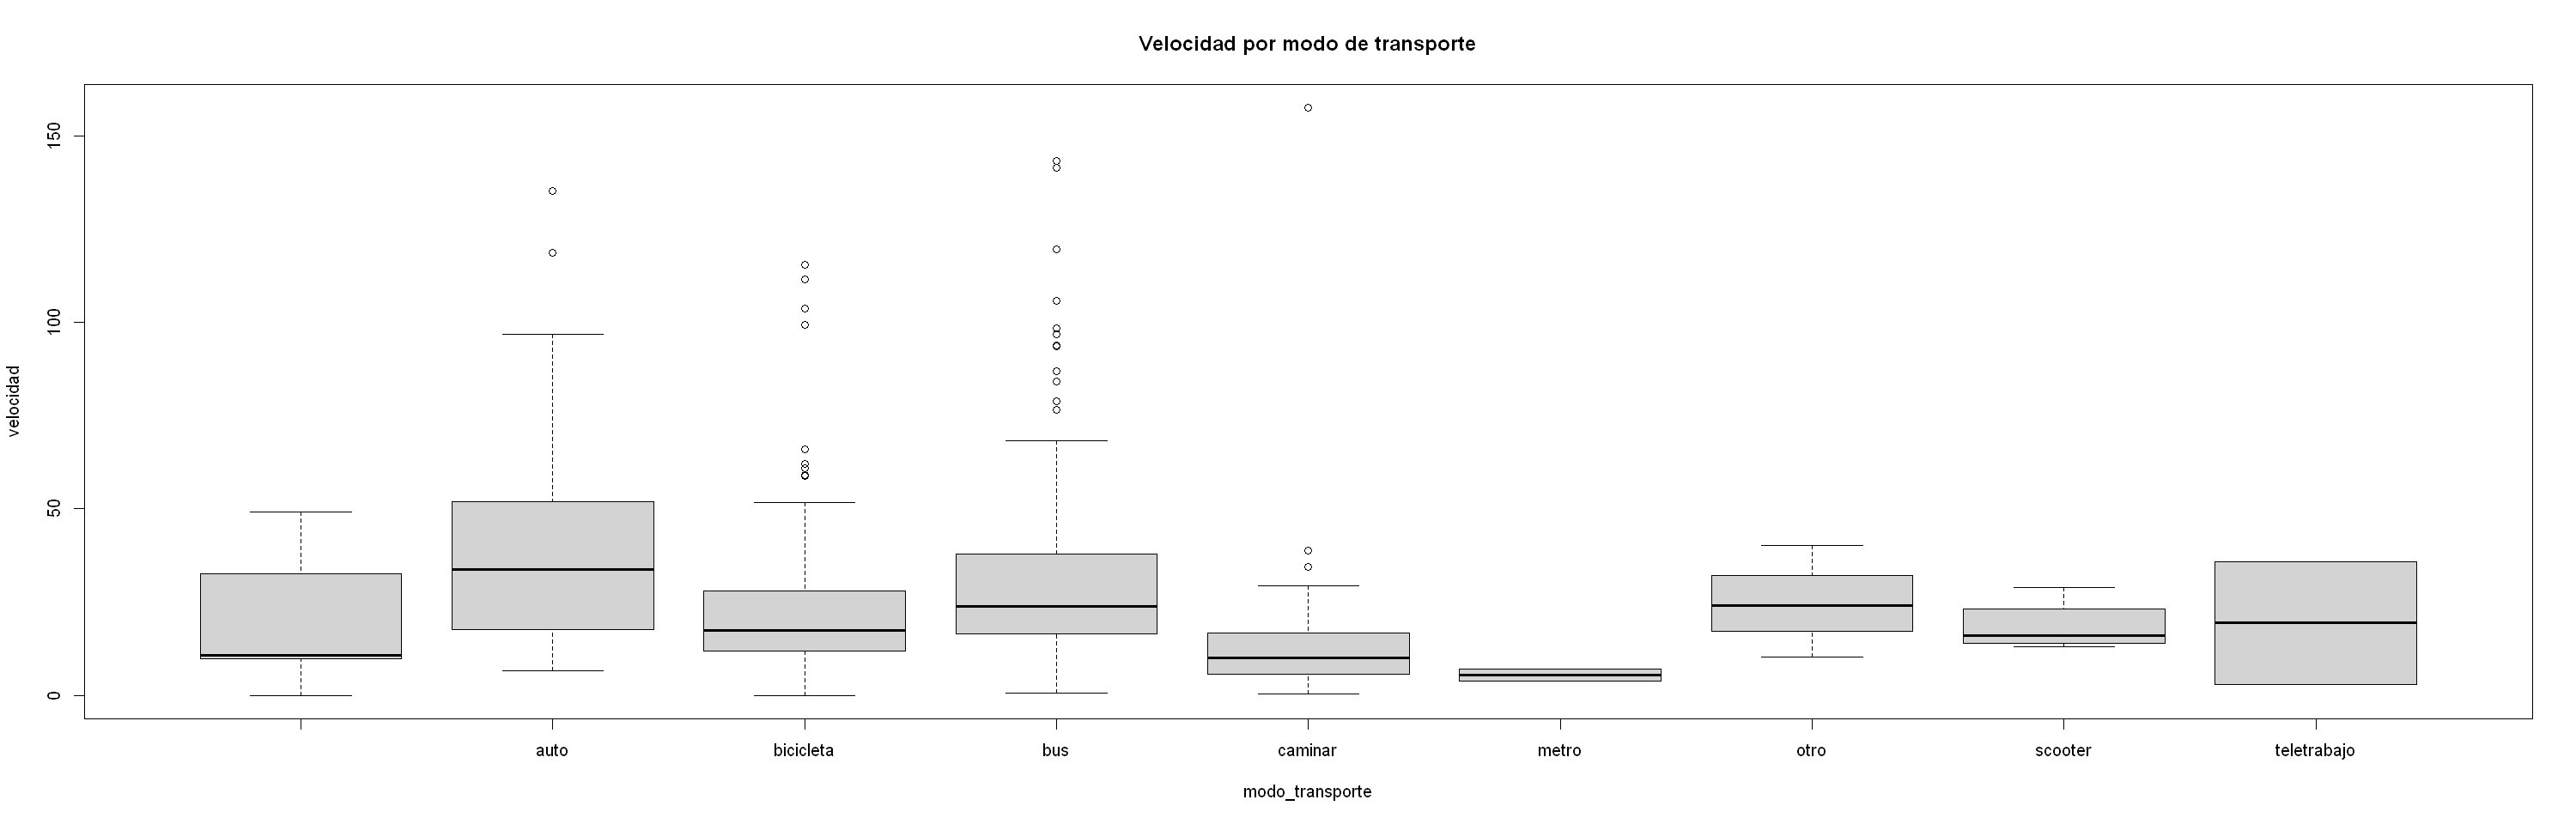

In [8]:
# Ver la magnitud del problema
summary(datos_grupo_numericos$tiempo)

# Filtrar outliers extremos con IQR
Q1 <- quantile(datos_grupo_numericos$tiempo, 0.25)
Q3 <- quantile(datos_grupo_numericos$tiempo, 0.75)
IQR_val <- Q3 - Q1

datos_grupo_numericos <- datos_grupo_numericos[
  datos_grupo_numericos$tiempo >= (Q1 - 3 * IQR_val) &
  datos_grupo_numericos$tiempo <= (Q3 + 3 * IQR_val), ]

res <- princomp(datos_grupo_numericos, cor=TRUE)
print(res)
plot(res) 

summary(datos_grupo)
boxplot(datos_grupo_numericos, main="Boxplot de Variables Numéricas")

boxplot(velocidad ~ modo_transporte, data=datos_grupo, main="Velocidad por modo de transporte")

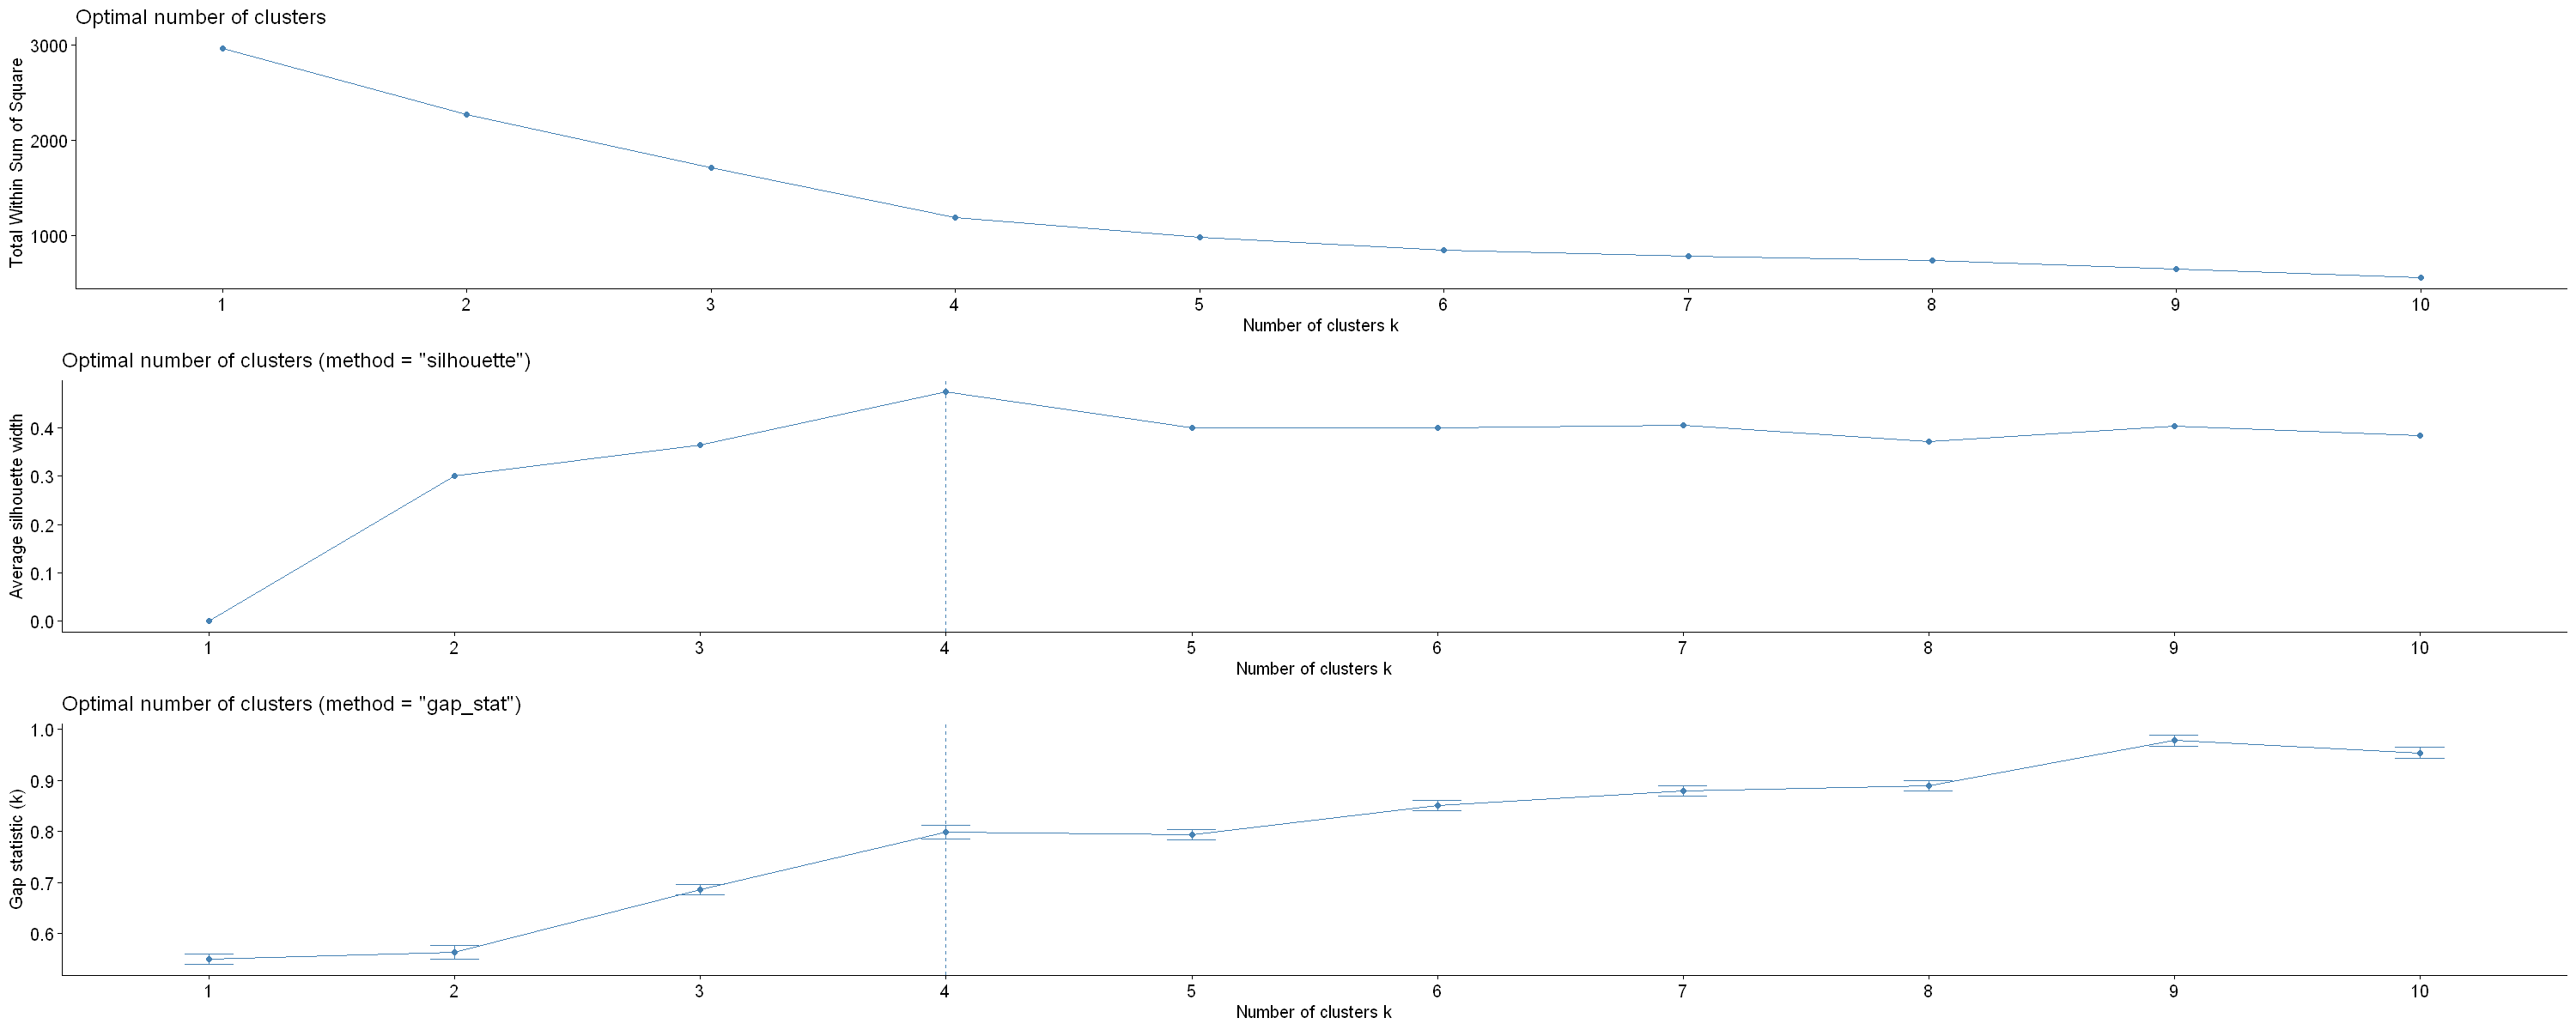

In [14]:
## Graficos de seleccion de K
datos_scale <- scale(datos_grupo_numericos)

### El "Codo" en formato ggplot
g1 <- fviz_nbclust(datos_scale, kmeans, method = "wss")

### Análisis de Silueta (Busca el máximo)
g2 <- fviz_nbclust(datos_scale, kmeans, method = "silhouette")

### Estadística Gap (Busca la mayor desviación del azar)
g3 <- fviz_nbclust(datos_scale, kmeans, method = "gap_stat")

options(repr.plot.height = 10) 
grid.arrange(g1, g2, g3, ncol = 1)
options(repr.plot.height = 8) 

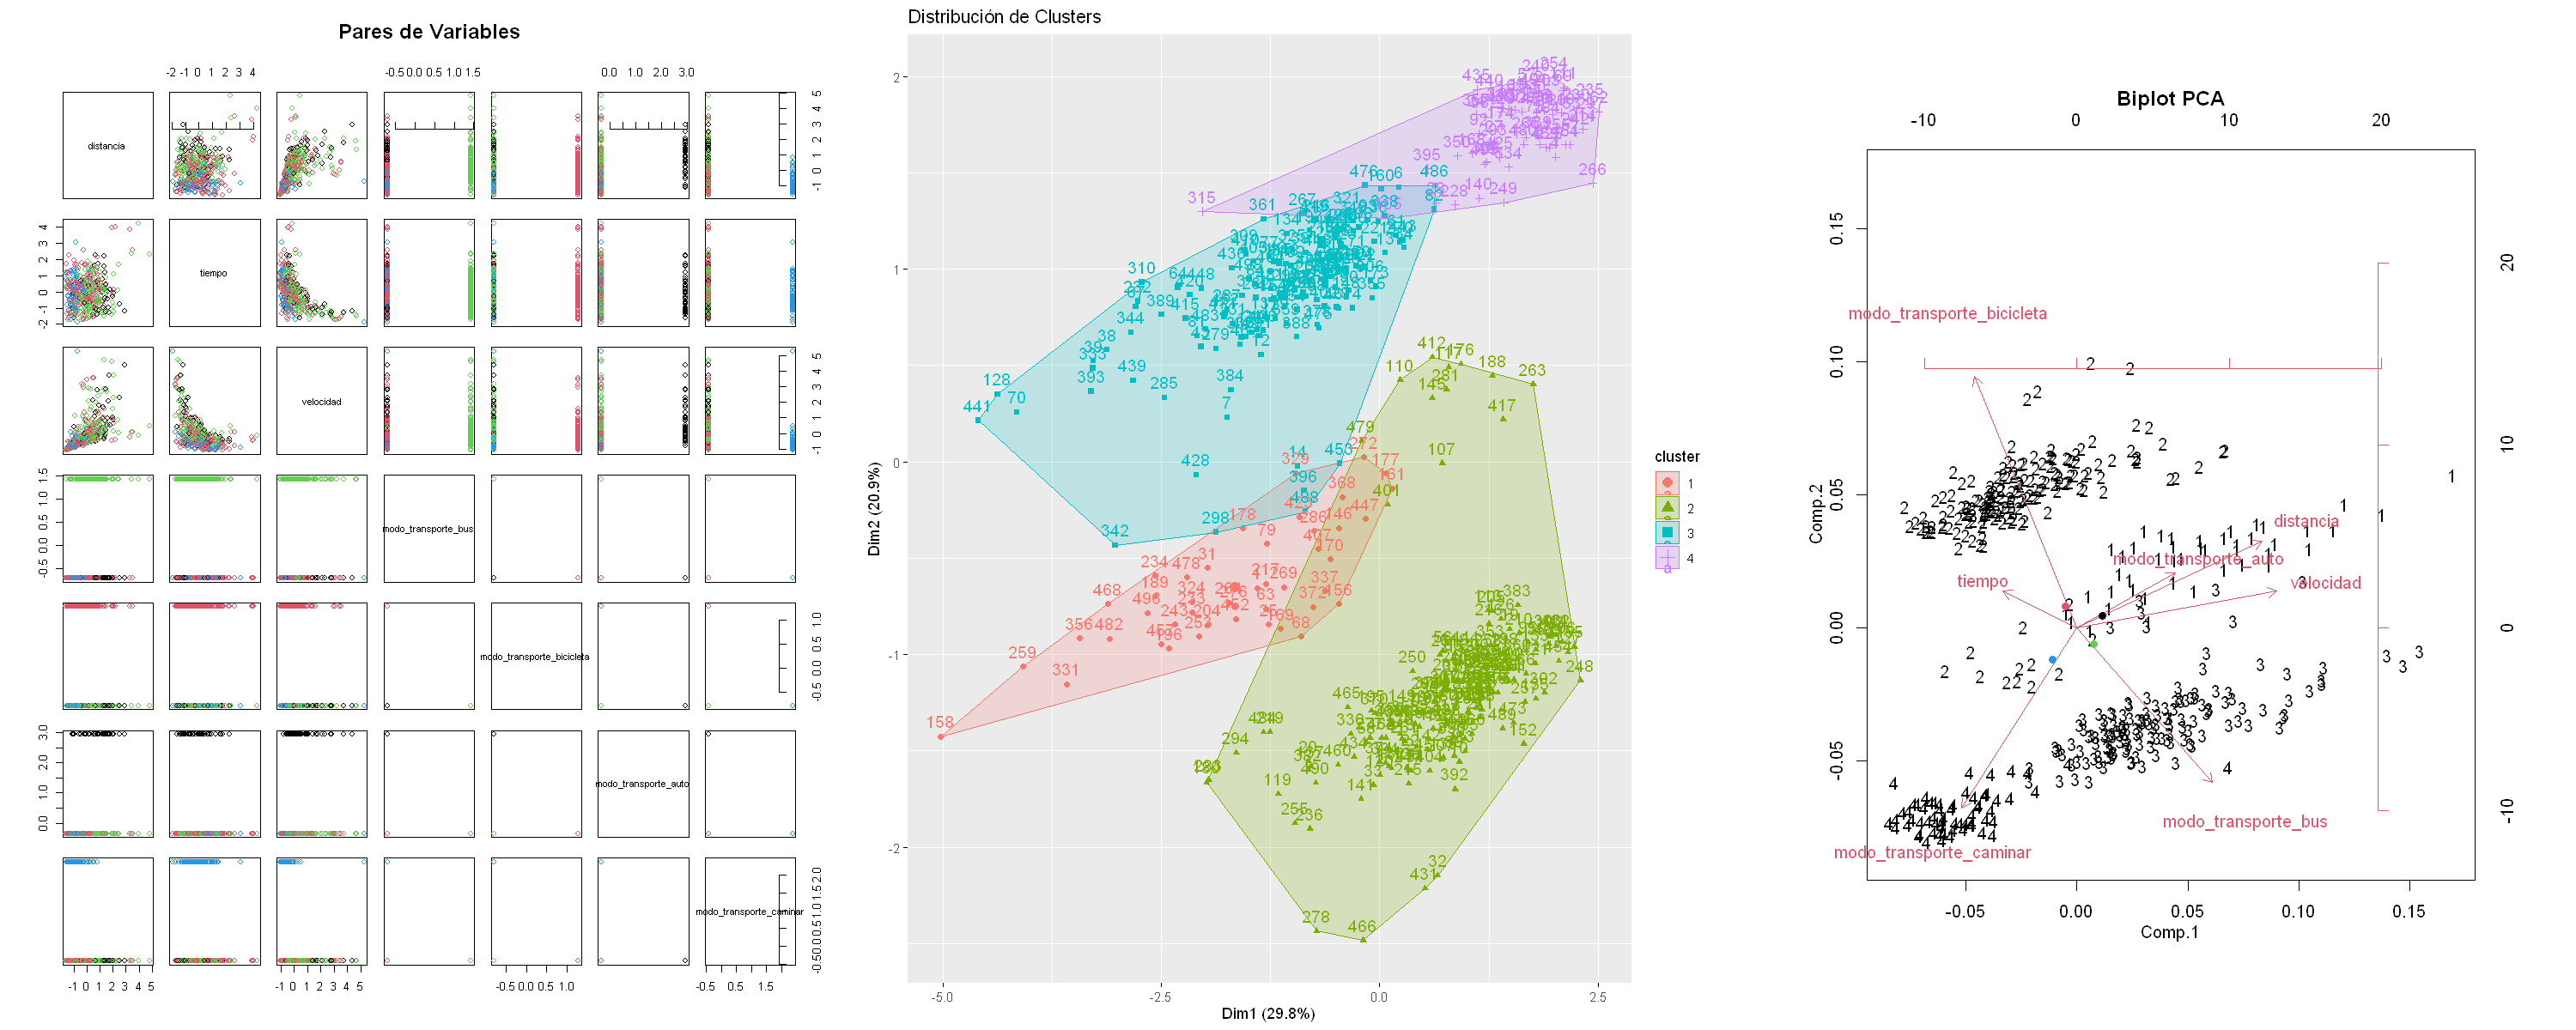

In [12]:
## Visualizacion de k
k0=4
cl<-kmeans(datos_scale,k0,iter.max=1000,nstart=10)

res <- princomp(datos_scale, cor=TRUE)
res2 <- predict(res, cl$centers)

# 1
p1 <- as.grob(~pairs(datos_scale, col=cl$cluster, main="Pares de Variables"))

# 2
p2 <- fviz_cluster(cl, datos_scale, main = "Distribución de Clusters")

# 3
p3 <- as.grob(~{
  biplot(res, xlabs=cl$cluster, main="Biplot PCA")
  points(res2[,1:2], col=1:k0, pch=19)
})

grid.arrange(p1, p2, p3, ncol = 3)

#### **Respuestas**
- **1. Describa los datos y discuta la pertinencia de realizar un análisis de clustering o agrupamiento**
    Los datos corresponden a registros de movilidad urbana de una ciudad intermedia, donde se describen los siguientes atributos por observación:

    - **viajes:** Cantidad de viajes diarios realizados
    - **distancia:** Distancia promedio por viaje (km)
    - **tiempo:** Tiempo promedio por viaje (minutos)
    - **modo_transporte:** Medio principal de transporte utilizado (auto, bus, bicicleta, caminar)

    El conjunto de datos presenta problemas de calidad documentados en el enunciado, incluyendo errores en el reporte del modo de transporte, inconsistencias y registros incompletos, lo que requirió un proceso de limpieza previo al análisis.
    Para el análisis se realizaron las siguientes decisiones de preprocesamiento, cada una justificada metodológicamente:

    - Se **agregó la variable velocidad promedio** (distancia/tiempo, expresada en km/h) como auxiliar al modo de transporte, dado que la variable modo_transporte es categórica y no es utilizable directamente en K-means. La velocidad permite diferenciar implícitamente entre modos de transporte, ya que cada medio tiene rangos de velocidad característicos.
    - La **variable modo_transporte tambien fue separada en multiples columnas tipo flag**. Es decir los valores categoricos fueron convertidos en numeros que pueden ser representados en los analisis.
    - Se **excluyó la variable viajes porque es la única que representa un conteo absoluto diario**, mientras que distancia, tiempo y velocidad son promedios por viaje y las columnas flag se complementaran con las otras columnas. Mezclar variables de distinta naturaleza y nivel de agregación distorsiona las métricas de distancia euclideana sobre las que opera K-means.
    
    **Respecto a los valores negativos en distancia, tiempo y viajes, se optó por eliminarlos**, interpretándolos como errores de digitación, dado que no modificaron significativamente los resultados (Se probo eliminando y pasandolos a valor abs y los resultados fueron similares, pero se determina que elimnarlos es la mejor idea).

    Finalmente, **se filtraron observaciones con velocidad superior a 160 km/h**, umbral determinado como el máximo físicamente razonable para el contexto urbano chileno, considerando que los tren EFE puede alcanzar esa velocidad en algunos tramos.

    Respecto a la pertinencia del análisis de clustering, este tipo de análisis es apropiado dado que el objetivo declarado es comprender cómo se mueven las personas para diseñar políticas de transporte diferenciadas. A diferencia de un análisis supervisado que parte de categorías predefinidas, el clustering permite identificar agrupaciones basadas exclusivamente en el comportamiento observado, sin asumir de antemano qué grupos existen. Esto es especialmente valioso en un contexto donde los datos presentan inconsistencias en la variable de modo de transporte, ya que los grupos obtenidos pueden revelar patrones reales de movilidad independientemente de la categoría declarada.

- **2. Utilice k-means para realizar el clustering de los datos y calcule el K óptimo.** 

    Luego de múltiples iteraciones explorando distintas combinaciones de variables, se determinó trabajar con "distancia", "tiempo", "velocidad" y las columnas tipo flag de "modo_transporte" como variables de entrada para el algoritmo K-means. 
    Para la selección del K óptimo se utilizaron tres criterios:
    
    - El **método del codo (WSS)** presenta una inflexión visible en K=4, a partir del cual la reducción se vuelve marginal.
    - El **análisis de silueta** alcanza su máximo en K=4 con un valor de aproximadamente 0.5, indicando una estructura de grupos moderada pero consistente.
    - La **estadística Gap** muestra un pico claro en K=4 seguido de una estabilización.

    Dado que los tres métodos convergen en K=4, y considerando que los datos contienen exactamente 4 modos de transporte válidos (auto, bus, bicicleta, caminar), se selecciona **K=4** como valor óptimo, respaldado tanto por los criterios estadísticos como por la interpretabilidad de dominio.

- **3. Caracterice los grupos obtenidos con el K óptimo. Interprete sus resultados**

    Con K=4 se obtiene una segmentación con separación visible entre grupos en el gráfico de distribución de clusters y el biplot PCA. Este último es especialmente revelador las flechas de cada modo de transporte apuntan en direcciones bien diferenciadas en el espacio de componentes principales, indicando que los clusters recuperan de forma natural los cuatro modos de transporte presentes en los datos, lo que valida tanto la elección de K como el preprocesamiento realizado.
    Los cuatro grupos se caracterizan de la siguiente manera:

    - **Cluster 1 (morado):** Dominado por la dirección de modo_transporte_bicicleta en el biplot. Corresponde a viajes en bicicleta, caracterizados por velocidades moderadas, distancias cortas a medias y tiempos relativamente bajos.
    - **Cluster 2 (rojo):** Ubicado en la dirección de modo_transporte_caminar. Corresponde a desplazamientos a pie, con las menores velocidades y distancias del conjunto, reflejando la naturaleza de la movilidad peatonal urbana.
    - **Cluster 3 (verde):** Asociado a modo_transporte_auto junto con distancia y velocidad en el biplot. Corresponde a viajes en automóvil, con las mayores velocidades y distancias considerables en tiempos relativamente bajos, indicando acceso a infraestructura vial eficiente.
    - **Cluster 4 (celeste):** Dominado por modo_transporte_bus. Corresponde a viajes en bus, caracterizados por distancias medias a largas pero con tiempos elevados, lo que refleja las condiciones de congestión mencionadas en el enunciado del problema.

    En términos del contexto del problema, la segmentación obtenida es coherente con la realidad de una ciudad intermedia con problemas de congestión y desigualdad en el acceso al transporte. El Cluster 4 (bus) representa la población potencialmente más afectada por deficiencias en infraestructura, registrando los peores ratios de velocidad efectiva para las distancias recorridas. El Cluster 2 (caminantes) podría indicar tanto una elección de movilidad activa como una carencia de alternativas para distancias cortas situación similar a la observada en ciudades diseñadas en torno al automóvil, donde la infraestructura peatonal es insuficiente. Los Clusters 1 y 3 representan perfiles con mejor acceso a infraestructura, ya sea ciclovías o red vial. Esta segmentación permite orientar políticas de transporte diferenciadas: mejora del transporte público para el Cluster 4, infraestructura ciclista para el Cluster 1, y alternativas peatonales seguras y accesibles para el Cluster 2.